# Geographic Visualization - Community Distribution across Italy

In [ ]:
# ── Repository root ───────────────────────────────────────────────────────────
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## 0 - Parameters

In [ ]:
# ── Input paths ───────────────────────────────────────────────────────────────
OBS_PATH         = ROOT / 'data' / 'raw' / 'observations_extended.csv.gz'   # fallback: observations.csv.gz
COMM_ANNUAL      = ROOT / 'data' / 'networks' / 'community_assignments_annual.csv.gz'
COMM_SEASONAL    = ROOT / 'data' / 'networks' / 'community_assignments_seasonal.csv.gz'
FIGURES_DIR      = ROOT / 'figures'

# ── Grid ──────────────────────────────────────────────────────────────────────
CELL_SIZE        = 0.1           
ITALY_BBOX       = (6.3, 35.3, 18.8, 47.5)   # (lon_min, lat_min, lon_max, lat_max)
MAP_ZOOM         = 7             

# ──────────
LOUVAIN_COL      = 'louvain_community'
ANNUAL_COMM_COL  = 'annual_community'
SEASONS          = ['winter_0', 'spring', 'summer', 'autumn', 'winter_1']
SEASON_NAMES     = {
    'winter_0': 'Winter\u2080', 'spring': 'Spring', 'summer': 'Summer',
    'autumn': 'Autumn', 'winter_1': 'Winter\u2081',
}
SEASON_PAL       = {
    'winter_0': '#5B8EB8', 'spring': '#7FB069',
    'summer': '#E0A040', 'autumn': '#C7563C', 'winter_1': '#5B8EB8',
}
# Community colors (coerenti con 06_community_detection_v1)
COMM_COLORS = [
    '#2C5F8A', '#4C9B7A', '#5B8EB8', '#E0A040',
    '#C7563C', '#7B61A8', '#8B4513', '#20B2AA',
    '#FF8C69', '#A0875A',
]

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Parameters set.')


Parameters set.


## 1 - Imports & setup

In [2]:
import subprocess, sys

for pkg, import_name in [
    ('geopandas', 'geopandas'),
    ('contextily', 'contextily'),
    ('shapely', 'shapely'),
    ('pyproj', 'pyproj'),
]:
    try:
        __import__(import_name)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import pyproj
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
import seaborn as sns
from shapely.geometry import box as shapely_box
from matplotlib.colors import Normalize
from collections import Counter

sns.set_theme(style='ticks', context='paper', font_scale=1.1, rc={
    'font.family': 'serif', 'axes.linewidth': 0.7,
})

def savefig(fig, name, dpi=300):
    for ext in ('png', 'pdf'):
        path = f'{FIGURES_DIR}/{name}.{ext}'
        fig.savefig(path, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
    print(f'  \U0001f4be {FIGURES_DIR}/{name}.png + .pdf')

print('Imports OK.')


Imports OK.


## 2 - Load & prepare data

In [3]:
# ── Observations ──────────────────────────────────────────────────────────────
obs_path = OBS_PATH

print(f'Loading observations from {obs_path}...')
obs = pd.read_csv(obs_path, usecols=['taxon_id', 'grid_cell', 'season'])
VALID_SEASONS = set(SEASONS)
obs = obs[obs['season'].isin(VALID_SEASONS)].copy()

# Parse grid cell coords (bottom-left corner of each 0.1° cell)
obs[['cell_lat', 'cell_lon']] = (
    obs['grid_cell'].str.split(',', expand=True).astype(float)
)
print(f'  {len(obs):,} observations | {obs["grid_cell"].nunique():,} unique cells')

# ── Community assignments ─────────────────────────────────────────────────────
print(f'Loading community assignments...')
comm_a = pd.read_csv(COMM_ANNUAL)
comm_s = pd.read_csv(COMM_SEASONAL)

# Merge obs → annual community
obs_c = obs.merge(
    comm_a[['taxon_id', LOUVAIN_COL, 'iconic_taxon']],
    on='taxon_id', how='inner'
)
obs_c = obs_c[obs_c[LOUVAIN_COL] >= 0].copy()   # drop isolates (-1)

all_comms = sorted(obs_c[LOUVAIN_COL].unique())
n_comms   = len(all_comms)

# Extend color list if needed
comm_colors_ext = COMM_COLORS.copy()
if n_comms > len(comm_colors_ext):
    extra = [mcm.tab20(i/20) for i in range(n_comms - len(comm_colors_ext))]
    comm_colors_ext += ['#{:02x}{:02x}{:02x}'.format(int(r*255),int(g*255),int(b*255))
                        for r,g,b,_ in extra]
COMM_COLOR = {c: comm_colors_ext[i] for i, c in enumerate(all_comms)}

print(f'  {len(comm_a):,} backbone nodes | {n_comms} communities')
print(f'  obs matched to backbone: {len(obs_c):,}')
print(f'  Community colors: {COMM_COLOR}')


Loading observations from data/observations_extended.csv...
  681,813 observations | 6,475 unique cells
Loading community assignments...
  3,009 backbone nodes | 8 communities
  obs matched to backbone: 627,847
  Community colors: {0: '#2C5F8A', 1: '#4C9B7A', 2: '#5B8EB8', 3: '#E0A040', 4: '#C7563C', 5: '#7B61A8', 6: '#8B4513', 7: '#20B2AA'}


In [5]:
# ── Helper: dominant community per cell ──────────────────────────────────────
def dominant_community_per_cell(obs_subset, comm_col=LOUVAIN_COL):
    """
    Per ogni grid cell: conta specie distinte per comunità,
    assegna la comunità con più specie come dominante.
    Usa species count (non obs count) per evitare bias da specie comuni.
    """
    dedup = obs_subset.drop_duplicates(["taxon_id", "grid_cell"])
    per_comm = (
        dedup
        .groupby(["cell_lat", "cell_lon", comm_col])
        .size().reset_index(name="n_species")
    )
    idx = per_comm.groupby(["cell_lat", "cell_lon"])["n_species"].idxmax()
    dominant = per_comm.loc[idx].copy()
    dominant.rename(columns={comm_col: "dominant_community"}, inplace=True)
    total = (
        dedup.groupby(["cell_lat", "cell_lon"])["taxon_id"].count()
        .reset_index(name="total_species")
    )
    dominant = dominant.merge(total, on=["cell_lat", "cell_lon"])
    dominant["dominance"] = dominant["n_species"] / dominant["total_species"]
    return dominant.reset_index(drop=True)


# ── Helper: GeoDataFrame con celle 0.1°×0.1° ──────────────────────────────────
def to_gdf(df, crs_out="EPSG:3857"):
    geoms = [
        shapely_box(r.cell_lon, r.cell_lat,
                    r.cell_lon + CELL_SIZE, r.cell_lat + CELL_SIZE)
        for r in df.itertuples()
    ]
    return gpd.GeoDataFrame(df.copy(), geometry=geoms, crs="EPSG:4326").to_crs(crs_out)


# ── FIX 1: Italia shape per clip ──────────────────────────────────────────────

try:
    # geopandas >= 0.12: datasets deprecati, usa geodatasets
    world_path = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(world_path)
    # Per ottenere solo Italia usiamo bbox filter
    italy_gdf = gpd.read_file(
        geodatasets.get_path("naturalearth.land"),
        bbox=(6.3, 35.3, 18.8, 47.5)
    ).to_crs("EPSG:3857")
except Exception:
    try:
        world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
        italy_gdf = world[world["name"] == "Italy"].to_crs("EPSG:3857")
    except Exception:
        italy_gdf = None
        print("⚠️  Italy shapefile non trovato — clip disabilitato")

def clip_to_italy(gdf):
    """Clip GeoDataFrame alla geometria dell"Italia. Fallback: nessun clip."""
    if italy_gdf is None or italy_gdf.empty:
        return gdf
    try:
        clipped = gpd.clip(gdf, italy_gdf)
        return clipped if len(clipped) > 0 else gdf
    except Exception:
        return gdf


# ── Helper: Italia bbox in Web Mercator ───────────────────────────────────────
tr = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
lon_min, lat_min, lon_max, lat_max = ITALY_BBOX
XMIN, YMIN = tr.transform(lon_min, lat_min)
XMAX, YMAX = tr.transform(lon_max, lat_max)

def clip_axes(ax):
    ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMIN, YMAX); ax.set_axis_off()

def add_basemap(ax, zoom=MAP_ZOOM):
    for provider in [
        ctx.providers.CartoDB.Positron,
        ctx.providers.CartoDB.PositronNoLabels,
        ctx.providers.OpenStreetMap.Mapnik,
    ]:
        try:
            ctx.add_basemap(ax, source=provider, zoom=zoom, alpha=0.6)
            return
        except Exception:
            continue

def plot_cells(ax, gdf, alpha_col="dominance", alpha_scale=1.0,
               fixed_color=None, fixed_alpha=None):
    """Disegna le celle sulla mappa con alpha proporzionale alla dominance."""
    for row in gdf.itertuples():
        col   = fixed_color or COMM_COLOR.get(row.dominant_community, "#AAAAAA")
        alpha = fixed_alpha or float(np.clip(
            getattr(row, alpha_col) * alpha_scale, 0.15, 0.95
        ))
        ax.add_patch(mpatches.Polygon(
            list(row.geometry.exterior.coords), closed=True,
            facecolor=col, alpha=alpha, edgecolor="none"
        ))

legend_handles = [
    mpatches.Patch(facecolor=COMM_COLOR[c], edgecolor="none",
                   alpha=0.85, label=f"C{c}")
    for c in all_comms
]
print("Helpers defined (with Italy clip).")


⚠️  Italy shapefile non trovato — clip disabilitato
Helpers defined (with Italy clip).


In [6]:
print('Computing dominant community per cell...')
dom_annual  = dominant_community_per_cell(obs_c)
dom = {s: dominant_community_per_cell(obs_c[obs_c['season'] == s])
       for s in SEASONS}

gdf_annual = to_gdf(dom_annual)
gdf_s      = {s: to_gdf(dom[s]) for s in SEASONS}

for name in ['annual'] + SEASONS:
    df = dom_annual if name == 'annual' else dom[name]
    print(f'  {name:<12}: {len(df):>5,} cells | '
          f'mean dominance={df["dominance"].mean():.2f}')


Computing dominant community per cell...
  annual      : 6,332 cells | mean dominance=0.63
  winter_0    : 3,035 cells | mean dominance=0.77
  spring      : 5,104 cells | mean dominance=0.68
  summer      : 5,548 cells | mean dominance=0.66
  autumn      : 4,737 cells | mean dominance=0.69
  winter_1    : 3,246 cells | mean dominance=0.76


## 3 - Fig 1: Annual + Winter₀ vs Summer

  💾 figures/geo_communities_annual_seasonal.png + .pdf


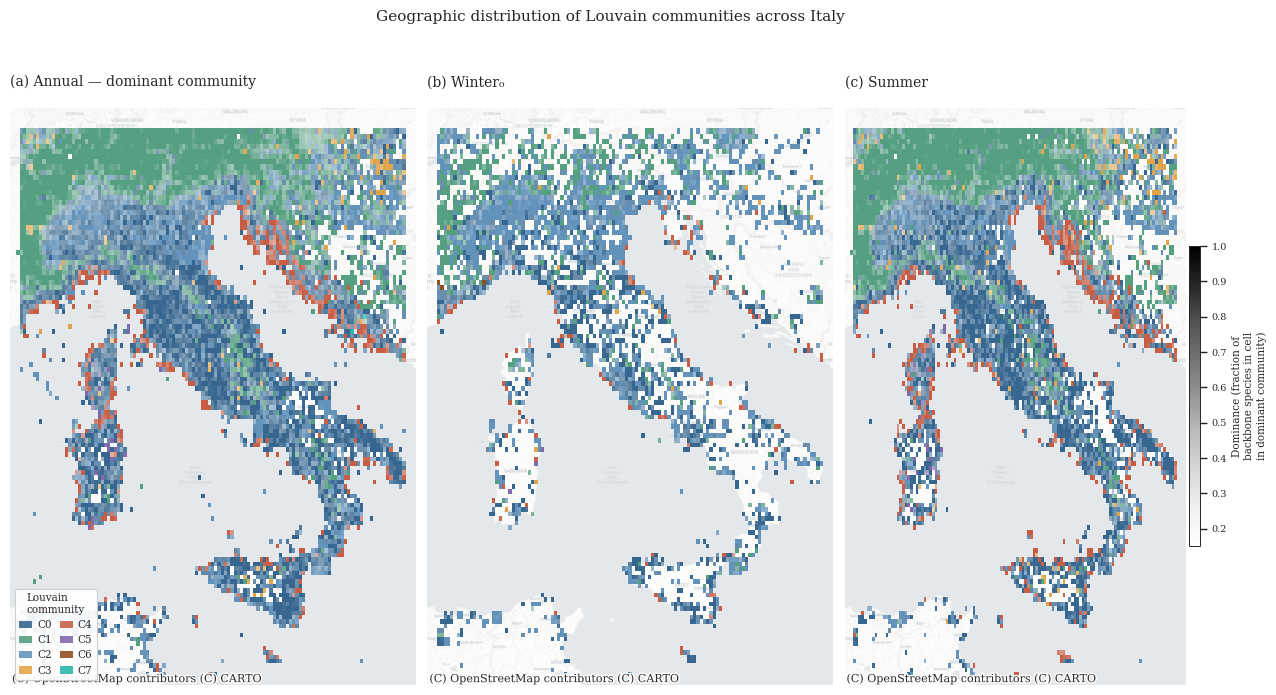

In [7]:
# Annual | Winter₀ | Summer — 3 pannelli
fig, axes = plt.subplots(1, 3, figsize=(16, 7.5),
                          gridspec_kw={"wspace": 0.03})

panels = [
    (gdf_annual,         dom_annual,   "(a) Annual — dominant community"),
    (gdf_s["winter_0"],  dom["winter_0"], "(b) Winter\u2080"),
    (gdf_s["summer"],    dom["summer"],   "(c) Summer"),
]

for ax, (gdf, dom_df, title) in zip(axes, panels):
    # FIX: clip alla geometria Italia prima di plottare
    gdf_clipped = clip_to_italy(gdf)
    # Init extent con bbox Italia (non con extent del GDF clippato)
    ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMIN, YMAX)
    plot_cells(ax, gdf_clipped, alpha_scale=1.4)
    add_basemap(ax)
    clip_axes(ax)
    ax.set_title(title, fontsize=10, loc="left", pad=5)

# FIX: legenda completa — ncols=2 per 8 comunità, bbox esplicita
axes[0].legend(
    handles=legend_handles, fontsize=7.5, frameon=True,
    framealpha=0.93, edgecolor="#cccccc",
    loc="lower left", title="Louvain\ncommunity", title_fontsize=7.5,
    ncol=2, handlelength=1.2, handletextpad=0.5, columnspacing=0.8,
)

sm = plt.cm.ScalarMappable(cmap="Greys", norm=Normalize(vmin=0.15, vmax=1.0))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.52, pad=0.01, aspect=28)
cbar.set_label("Dominance (fraction of\nbackbone species in cell\nin dominant community)",
               fontsize=7.5)
cbar.ax.tick_params(labelsize=7)

fig.suptitle("Geographic distribution of Louvain communities across Italy",
             fontsize=11, y=1.01)
fig.tight_layout()
savefig(fig, "geo_communities_annual_seasonal")
plt.show()


## 4 - Fig 2: Facet maps — one panel per community

  💾 figures/geo_community_facets.png + .pdf


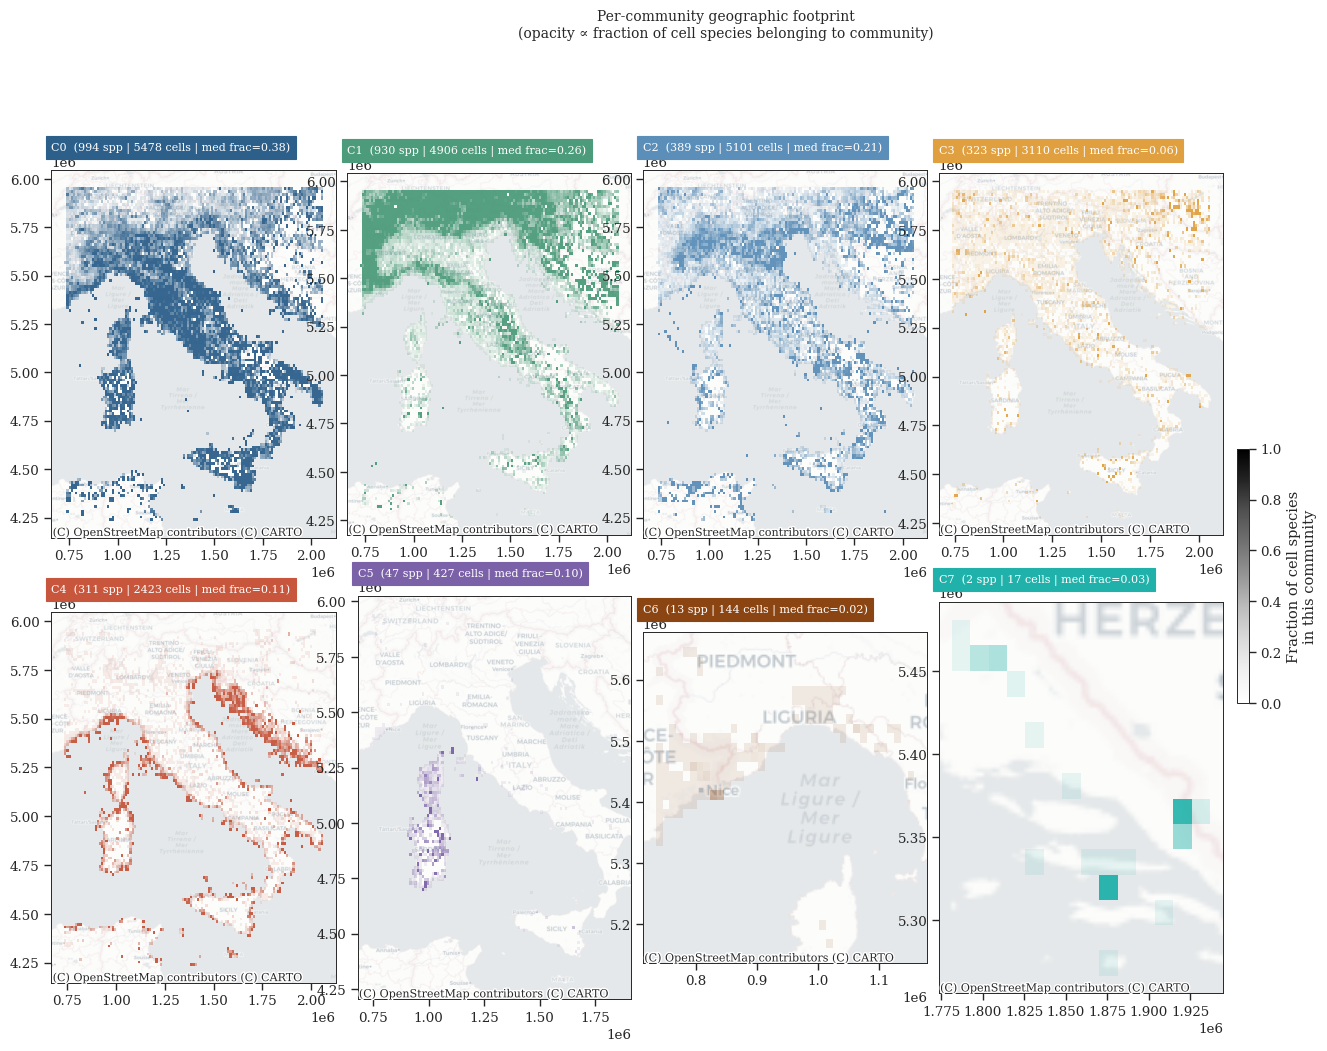

In [ ]:
dedup_all = obs_c.drop_duplicates(['taxon_id', 'grid_cell'])

per_comm = (
    dedup_all
    .groupby(['cell_lat', 'cell_lon', LOUVAIN_COL])
    .size().reset_index(name='n_species_comm')
)
total_per_cell = (
    dedup_all.groupby(['cell_lat', 'cell_lon'])['taxon_id'].count()
    .reset_index(name='total_species')
)
per_comm = per_comm.merge(total_per_cell, on=['cell_lat', 'cell_lon'])
per_comm['fraction'] = per_comm['n_species_comm'] / per_comm['total_species']

# Layout
ncols = min(4, n_comms)
nrows = (n_comms + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4.5*ncols, 5.5*nrows),
                          gridspec_kw={'wspace': 0.04, 'hspace': 0.10})
axes = np.array(axes).reshape(nrows, ncols)

for idx, comm_id in enumerate(all_comms):
    ri, ci = idx // ncols, idx % ncols
    ax = axes[ri, ci]

    df_c = per_comm[per_comm[LOUVAIN_COL] == comm_id].copy()
    if df_c.empty:
        ax.set_axis_off(); continue

    gdf_c = to_gdf(df_c.rename(columns={'n_species_comm': 'n_species'}))
    gdf_c['fraction'] = df_c['fraction'].values

    gdf_c.plot(ax=ax, color='none', edgecolor='none')   # init extent
    base_col = COMM_COLOR[comm_id]
    for row in gdf_c.itertuples():
        alpha = float(np.clip(row.fraction * 1.8, 0.10, 0.95))
        ax.add_patch(mpatches.Polygon(
            list(row.geometry.exterior.coords), closed=True,
            facecolor=base_col, alpha=alpha, edgecolor='none'
        ))

    add_basemap(ax, zoom=6)

    n_cells = len(df_c)
    med_frac = df_c['fraction'].median()
    n_spp    = (comm_a[LOUVAIN_COL] == comm_id).sum() if LOUVAIN_COL in comm_a.columns else '?'
    ax.set_title(
        f'C{comm_id}  ({n_spp} spp | {n_cells} cells | med frac={med_frac:.2f})',
        fontsize=8, loc='left', pad=4,
        color='white', backgroundcolor=base_col
    )

# Hide unused
for idx in range(n_comms, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_axis_off()

# Fraction intensity colorbar
sm2 = plt.cm.ScalarMappable(cmap='Greys', norm=Normalize(0, 1))
sm2.set_array([])
fig.colorbar(sm2, ax=axes.ravel().tolist(), shrink=0.3, aspect=22, pad=0.01,
             label='Fraction of cell species\nin this community')

fig.suptitle('Per-community geographic footprint\n'
             '(opacity ∝ fraction of cell species belonging to community)',
             fontsize=10, y=1.01)
savefig(fig, 'geo_community_facets')
plt.show()


## 5 - Fig 3: Seasonal shift — where does the dominant community change?

  💾 figures/geo_seasonal_shift.png + .pdf


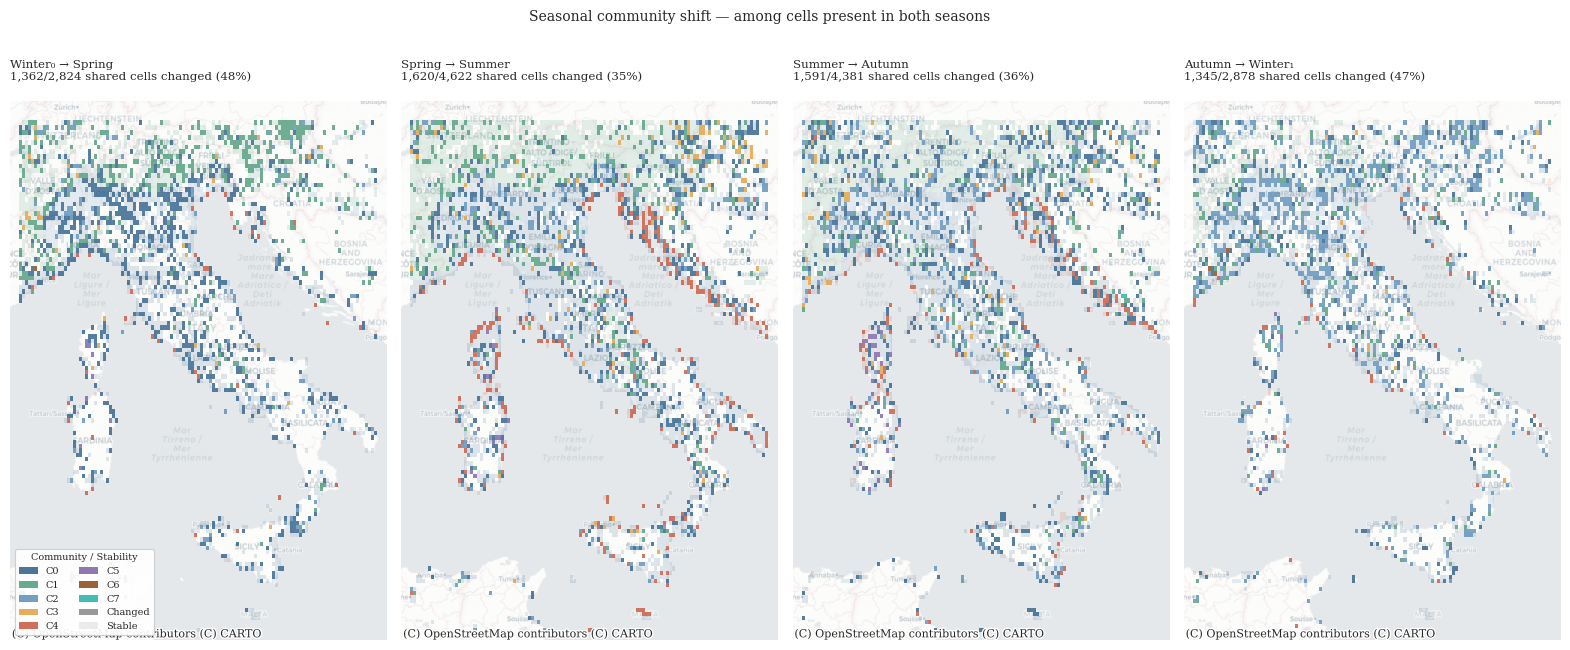

In [10]:
# Per ogni coppia adiacente: celle presenti in ENTRAMBE le stagioni
# FIX: inner join — non conta le celle assenti come "cambiate"
# Colore = comunità nella stagione più recente
# Opaco = cambiata, trasparente = stabile

adjacent_pairs = [
    ("winter_0", "spring"),
    ("spring",   "summer"),
    ("summer",   "autumn"),
    ("autumn",   "winter_1"),
]

fig, axes = plt.subplots(1, len(adjacent_pairs),
                          figsize=(5*len(adjacent_pairs), 7),
                          gridspec_kw={"wspace": 0.04})

shift_stats = {}

for ax, (s1, s2) in zip(axes, adjacent_pairs):
    d1 = dom[s1][["cell_lat","cell_lon","dominant_community"]].rename(
        columns={"dominant_community": "comm_s1"})
    d2 = dom[s2][["cell_lat","cell_lon","dominant_community"]].rename(
        columns={"dominant_community": "comm_s2"})

    # FIX: inner join — solo celle presenti in ENTRAMBE le stagioni
    merged = d1.merge(d2, on=["cell_lat","cell_lon"], how="inner")
    merged["changed"] = (merged["comm_s1"] != merged["comm_s2"])
    # Colore = comunità in s2 (stagione più recente)
    merged["plot_comm"] = merged["comm_s2"]

    n_changed = merged["changed"].sum()
    n_total   = len(merged)
    pct       = 100 * n_changed / n_total
    shift_stats[(s1, s2)] = {"n_changed": int(n_changed),
                              "n_shared":  int(n_total), "pct": round(pct, 1)}

    gdf_shift = clip_to_italy(to_gdf(merged))
    ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMIN, YMAX)

    for row in gdf_shift.itertuples():
        col   = COMM_COLOR.get(row.plot_comm, "#AAAAAA")
        # Cambiata → opaco, stabile → sbiadito
        alpha = 0.80 if row.changed else 0.15
        ax.add_patch(mpatches.Polygon(
            list(row.geometry.exterior.coords), closed=True,
            facecolor=col, alpha=alpha, edgecolor="none"
        ))

    add_basemap(ax, zoom=6)
    clip_axes(ax)
    ax.set_title(
        f"{SEASON_NAMES[s1]} → {SEASON_NAMES[s2]}\n"
        f"{n_changed:,}/{n_total:,} shared cells changed ({pct:.0f}%)",
        fontsize=8.5, loc="left", pad=5
    )

# Legend
legend_items = legend_handles + [
    mpatches.Patch(facecolor="grey", alpha=0.80, edgecolor="none", label="Changed"),
    mpatches.Patch(facecolor="grey", alpha=0.15, edgecolor="none", label="Stable"),
]
axes[0].legend(
    handles=legend_items, fontsize=7, frameon=True, framealpha=0.93,
    edgecolor="#cccccc", loc="lower left",
    title="Community / Stability", title_fontsize=7, ncol=2
)

fig.suptitle("Seasonal community shift — among cells present in both seasons",
             fontsize=10, y=1.01)
fig.tight_layout()
savefig(fig, "geo_seasonal_shift")
plt.show()


## 6 - Fig 4: Backbone species richness per cell, colored by dominant community

  💾 figures/geo_richness_dominance.png + .pdf


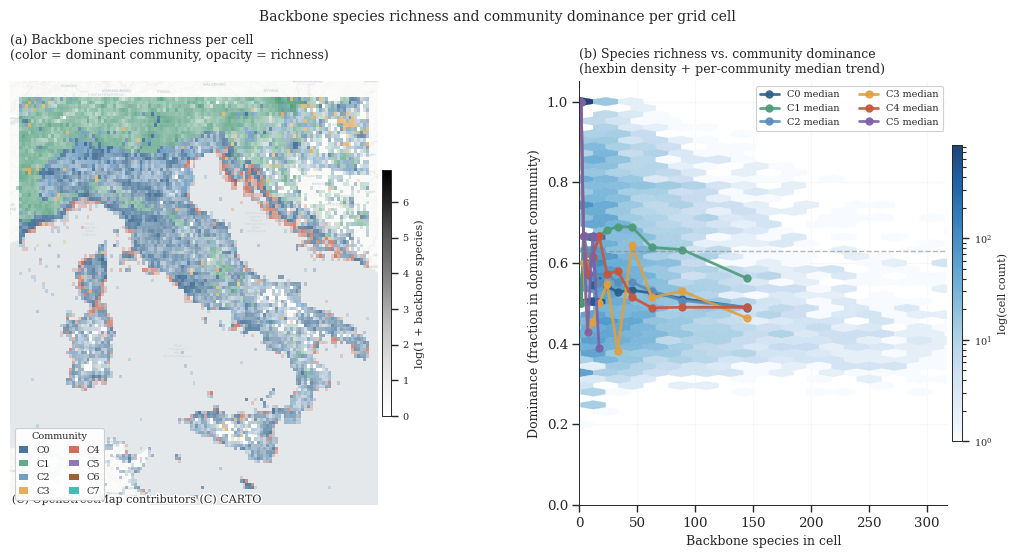

In [11]:
# FIX: hexbin invece di scatter per panel (b) — evita overplotting
# Panel (a): richness map con clip Italia
# Panel (b): hexbin richness vs dominance, separato per comunità

cell_stats = dom_annual.copy()
obs_per_cell = (
    obs.groupby(["cell_lat", "cell_lon"])
    .size().reset_index(name="total_obs")
)
cell_stats = cell_stats.merge(obs_per_cell, on=["cell_lat","cell_lon"], how="left")
cell_stats["total_obs"] = cell_stats["total_obs"].fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                gridspec_kw={"wspace": 0.30})

# ── Panel A: richness map ─────────────────────────────────────────────────────
gdf_rich = clip_to_italy(to_gdf(cell_stats))
ax1.set_xlim(XMIN, XMAX); ax1.set_ylim(YMIN, YMAX)
max_sp = cell_stats["total_species"].max()
for row in gdf_rich.itertuples():
    col   = COMM_COLOR.get(row.dominant_community, "#AAAAAA")
    alpha = float(np.clip(0.15 + 0.80 * np.log1p(row.total_species) /
                           np.log1p(max_sp), 0.12, 0.95))
    ax1.add_patch(mpatches.Polygon(
        list(row.geometry.exterior.coords), closed=True,
        facecolor=col, alpha=alpha, edgecolor="none"
    ))
add_basemap(ax1, zoom=7)
clip_axes(ax1)

sm3 = plt.cm.ScalarMappable(cmap="Greys", norm=Normalize(0, np.log1p(max_sp)))
sm3.set_array([])
cbar3 = plt.colorbar(sm3, ax=ax1, shrink=0.58, pad=0.01, aspect=28)
cbar3.set_label("log(1 + backbone species)", fontsize=8)
cbar3.ax.tick_params(labelsize=7)
ax1.set_title("(a) Backbone species richness per cell\n"
              "(color = dominant community, opacity = richness)",
              fontsize=9, loc="left")
ax1.legend(handles=legend_handles, fontsize=7, frameon=True, framealpha=0.93,
           edgecolor="#cccccc", loc="lower left", title="Community",
           title_fontsize=7, ncol=2, handlelength=1.0)

# ── Panel B: hexbin richness vs dominance ─────────────────────────────────────
# FIX: hexbin per ogni comunità — linee mediane invece di scatter
from matplotlib.colors import LogNorm

hb = ax2.hexbin(
    cell_stats["total_species"], cell_stats["dominance"],
    gridsize=45, cmap="Blues", mincnt=1, bins="log",
    linewidths=0.2, alpha=0.9
)
cbar4 = plt.colorbar(hb, ax=ax2, shrink=0.7, pad=0.01, aspect=28)
cbar4.set_label("log(cell count)", fontsize=8)
cbar4.ax.tick_params(labelsize=7)

# Trend mediano per comunità (bin mediani)
bins_edge = np.percentile(cell_stats["total_species"], np.linspace(5, 95, 12))
for comm_id in all_comms:
    sub = cell_stats[cell_stats["dominant_community"] == comm_id].copy()
    if len(sub) < 10:
        continue
    sub["bin"] = pd.cut(sub["total_species"], bins=bins_edge, labels=False)
    trend = sub.groupby("bin")["dominance"].median().dropna()
    centers = [(bins_edge[int(i)] + bins_edge[min(int(i)+1, len(bins_edge)-1)])/2
               for i in trend.index]
    ax2.plot(centers, trend.values, "-o", color=COMM_COLOR[comm_id],
             lw=2, ms=5, alpha=0.9, label=f"C{comm_id} median")

ax2.set_xlabel("Backbone species in cell", fontsize=9)
ax2.set_ylabel("Dominance (fraction in dominant community)", fontsize=9)
ax2.set_title("(b) Species richness vs. community dominance\n"
              "(hexbin density + per-community median trend)",
              fontsize=9, loc="left")
ax2.legend(fontsize=7, frameon=True, framealpha=0.93, edgecolor="#cccccc",
           ncol=2, loc="upper right")
ax2.set_ylim(0, 1.05)
ax2.set_xlim(0, cell_stats["total_species"].quantile(0.99))
ax2.axhline(cell_stats["dominance"].mean(), color="#888888", ls="--",
            lw=1, alpha=0.6, label=f"Mean={cell_stats["dominance"].mean():.2f}")
ax2.grid(True, alpha=0.15)
sns.despine(ax=ax2)

fig.suptitle("Backbone species richness and community dominance per grid cell",
             fontsize=10, y=1.01)
fig.tight_layout()
savefig(fig, "geo_richness_dominance")
plt.show()


## 7 - Summary statistics

In [12]:
print("=" * 65)
print("GEOGRAPHIC SUMMARY")
print("=" * 65)
print(f"Grid: {CELL_SIZE}° × {CELL_SIZE}° (≈11×8 km per cell at 42°N)")
print(f"Total cells with backbone species (annual): {len(dom_annual):,}")
print(f"Italy bbox: lon {ITALY_BBOX[0]}–{ITALY_BBOX[2]}°E, "
      f"lat {ITALY_BBOX[1]}–{ITALY_BBOX[3]}°N")
italy_note = "(clipped to Italy shape)" if italy_gdf is not None else "(bbox only — no shape clip)"
print(f"Clip: {italy_note}")
print()

print(f"  {'Community':<12} {'Cells':>7} {'%cells':>7} {'Median dom':>11} {'Med species':>12}")
print("  " + "-" * 55)
for comm_id in all_comms:
    mask = dom_annual["dominant_community"] == comm_id
    sub  = dom_annual[mask]
    pct  = 100 * len(sub) / len(dom_annual)
    med_dom = sub["dominance"].median() if len(sub) > 0 else float("nan")
    med_sp  = sub["total_species"].median() if len(sub) > 0 else float("nan")
    print(f"  C{comm_id:<11} {len(sub):>7,} {pct:>7.1f}% {med_dom:>11.3f} {med_sp:>12.1f}")

print()
print("Seasonal cell counts:")
for s in SEASONS:
    print(f"  {SEASON_NAMES[s]:<10}: {len(dom[s]):>5,} cells")

print()
print("Seasonal shift — INNER JOIN (shared cells only):")
print(f"  {'Transition':<25} {'Changed':>8} {'Shared':>8} {'%changed':>10}")
print("  " + "-" * 55)
for (s1, s2), stat in shift_stats.items():
    label = f"{SEASON_NAMES[s1]} → {SEASON_NAMES[s2]}"
    print(f"  {label:<25} {stat["n_changed"]:>8,} {stat["n_shared"]:>8,} "
          f"{stat["pct"]:>9.1f}%")
print()
print("Note: % changed calcolato solo su celle presenti in ENTRAMBE le stagioni.")
print("Con outer join i valori erano sovrastimati (celle assenti contavano come cambiate).")


GEOGRAPHIC SUMMARY
Grid: 0.1° × 0.1° (≈11×8 km per cell at 42°N)
Total cells with backbone species (annual): 6,332
Italy bbox: lon 6.3–18.8°E, lat 35.3–47.5°N
Clip: (bbox only — no shape clip)

  Community      Cells  %cells  Median dom  Med species
  -------------------------------------------------------
  C0             2,863    45.2%       0.542         21.0
  C1             1,796    28.4%       0.665         36.0
  C2             1,103    17.4%       0.596         18.0
  C3               107     1.7%       0.511         69.0
  C4               437     6.9%       0.667          9.0
  C5                24     0.4%       1.000          1.5
  C6                 0     0.0%         nan          nan
  C7                 2     0.0%       0.750          2.5

Seasonal cell counts:
  Winter₀   : 3,035 cells
  Spring    : 5,104 cells
  Summer    : 5,548 cells
  Autumn    : 4,737 cells
  Winter₁   : 3,246 cells

Seasonal shift — INNER JOIN (shared cells only):
  Transition                 Chan